# A1 Benchmark & Analysis

This notebook post-processes and compares an **arbitrary set** of trusted run checkpoints.  
Edit the `RUN_IDS` list in **Section 3** to add or remove runs — everything else adapts automatically.

**Pipeline:**
1. Clone repo & install deps
2. Mount Google Drive (runs live there)
3. Run `postprocess_run.py --benchmark` for every run in `RUN_IDS`
4. Load the produced `summary.json` and `benchmark.json` files
5. Display learning curves, confusion matrices, and a comparison table

## 1 — Colab Setup

In [ ]:
!git clone --branch a1-draft-test https://github.com/TuanKhai1210/Deep-Learning-Benchmark-Suite.git
%cd Deep-Learning-Benchmark-Suite
!pip install -e .

Cloning into 'Deep-Learning-Benchmark-Suite'...
remote: Enumerating objects: 927, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 927 (delta 19), reused 45 (delta 13), pack-reused 842 (from 1)
Receiving objects: 100% (927/927), 573.08 KiB | 17.91 MiB/s, done.
Resolving deltas: 100% (488/488), done.
/content/Deep-Learning-Benchmark-Suite
Obtaining file:///content/Deep-Learning-Benchmark-Suite
  Preparing metadata (setup.py) ... done
  Running setup.py develop for deep-learning-benchmark-suite


In [ ]:
import sys
import json
import pprint
from pathlib import Path
from IPython.display import Image, display

# Add the project root to sys.path so we can import from src
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

## 2 — Mount Google Drive

Your run directories must be accessible on the Colab VM.  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/dlbench_runs"

In [ ]:
from pathlib import Path

project_root = Path(".").resolve()

repo_runs_dir = project_root / "runs"
drive_dlbench_runs_dir = Path("/content/drive/MyDrive/dlbench_runs")

# Remove the existing 'runs' directory if it's not already a symlink
if repo_runs_dir.exists() and not repo_runs_dir.is_symlink():
    !rm -rf {repo_runs_dir}

# Create a symbolic link from the runs folder to the Google Drive directory
!ln -s {drive_dlbench_runs_dir} {repo_runs_dir}

print(f"Symlink created: {repo_runs_dir} -> {repo_runs_dir.resolve()}")

Symlink created: /content/Deep-Learning-Benchmark-Suite/runs -> /content/drive/MyDrive/dlbench_runs


In [ ]:
!mkdir -p "/content/drive/MyDrive/dlbench_analysis"

In [ ]:
from pathlib import Path

# Inherit project_root from the notebook state
if "project_root" not in globals():
    project_root = Path(".").resolve()

analysis_dir = project_root / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
drive_dlbench_analysis_dir = Path("/content/drive/MyDrive/dlbench_analysis")

# Remove the existing 'analysis' directory if it's not already a symlink
if analysis_dir.exists() and not analysis_dir.is_symlink():
    !rm -rf {analysis_dir}

# Create a symbolic link from the analysis folder to the Google Drive directory
!ln -s {drive_dlbench_analysis_dir} {analysis_dir}

print(f"Symlink created: {analysis_dir} -> {analysis_dir.resolve()}")

Symlink created: /content/Deep-Learning-Benchmark-Suite/analysis -> /content/drive/MyDrive/dlbench_analysis


In [ ]:
def grid_shape(n: int, ncols_max: int = 3) -> tuple:
    """Return (nrows, ncols) for a compact grid that fits n panels.

    ncols grows up to ncols_max, then nrows increases.
    Examples:
      n=1 -> (1,1)  n=2 -> (1,2)  n=3 -> (1,3)
      n=4 -> (2,2)  n=5 -> (2,3)  n=6 -> (2,3)
      n=7 -> (3,3)  n=9 -> (3,3)
    """
    if n == 0:
        raise ValueError("Need at least one run")
    ncols = min(n, ncols_max)
    nrows = math.ceil(n / ncols)
    return nrows, ncols


print("grid_shape helper ready.")

grid_shape helper ready.


## 3 — Define Run IDs

**Add or remove entries freely** — all downstream cells adapt to the list length.

In [ ]:
import math
from pathlib import Path

# ── Add / remove run IDs here ─────────────────────────────────────────────────
RUN_IDS = [
    "a1_linear_main_seed69420_20260920-071742_9e5d8b",
    "a1_mlp_main_seed69420_20260920-073429_497541",
    "a1_linear_main_seed69420_20260920-114825_3d2881",
    "a1_mlp_main_seed69420_20260920-120316_b22d28",
]
# ─────────────────────────────────────────────────────────────────────────────

# Ensure base paths from previous cells are loaded or fall back gracefully
if "repo_runs_dir" not in globals():
    project_root = Path(".").resolve()
    repo_runs_dir = project_root / "runs"

RUNS_BASE = repo_runs_dir

# Reuse the analysis_dir defined earlier instead of redefining it
if "analysis_dir" not in globals():
    project_root = Path(".").resolve()
    analysis_dir = project_root / "analysis"

ANALYSIS_ROOT = analysis_dir
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

# Verify every run directory exists before doing anything
missing = [r for r in RUN_IDS if not (RUNS_BASE / "a1" / r).is_dir()]
if missing:
    raise FileNotFoundError("Missing run directories:\n" + "\n".join(f"  {RUNS_BASE / "a1" / r}" for r in missing))

print(f"{len(RUN_IDS)} run(s) found:")
for run_id in RUN_IDS:
    print("  \u2713", run_id)

4 run(s) found:
  ✓ a1_linear_main_seed69420_20260920-071742_9e5d8b
  ✓ a1_mlp_main_seed69420_20260920-073429_497541
  ✓ a1_linear_main_seed69420_20260920-114825_3d2881
  ✓ a1_mlp_main_seed69420_20260920-120316_b22d28


In [ ]:
!pip list

Package                               Version            Editable project location
------------------------------------- ------------------ --------------------------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                3.0.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.1
altair                                5.5.0
annotated-doc                         0.0.5
annotated-types                       0.8.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
anywidget      

## 4 — Run `postprocess_run.py` for Each Checkpoint

`--benchmark` requires a GPU runtime (Runtime → Change runtime type → T4 GPU).  
If you want analysis-only (no timing), remove `--benchmark` from the `cmd` list below.

In [ ]:
import subprocess
import sys
import json
from pathlib import Path
from dlbench.a1.data.dataset import prepare_data

# Rely on already declared global variables
RUNS_BASE = globals().get("RUNS_BASE", Path("./runs").resolve())
ANALYSIS_ROOT = globals().get("ANALYSIS_ROOT", Path("./analysis").resolve())

OUTPUT_DIRS = {}

for run_id in RUN_IDS:
    run_dir = RUNS_BASE / "a1" / run_id
    out_dir = ANALYSIS_ROOT / run_id
    OUTPUT_DIRS[run_id] = out_dir

    if out_dir.exists():
        print(f"[SKIP] {run_id} \u2014 output already exists")
        continue

    # Load config.json from the run directory
    config_path = run_dir / "config.json"
    if config_path.exists():
        try:
            with open(config_path, "r") as f:
                run_config = json.load(f)
            prepare_data(run_config)
        except Exception as e:
            print(f"[WARNING] Could not preload dataset from config: {e}")

    print(f"\n\u2500\u2500 Processing {run_id} \u2500\u2500")
    cmd = [
        sys.executable, "scripts/postprocess_run.py",
        "--run-dir",    str(run_dir),
        "--output-dir", str(out_dir),
        "--trust-checkpoint",
        "--benchmark",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError(f"postprocess_run failed for {run_id}")

print(f"\nDone. {len(OUTPUT_DIRS)} run(s) processed.")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.11MB/s]



── Processing a1_linear_main_seed69420_20260920-071742_9e5d8b ──
Saved validation analysis to /content/Deep-Learning-Benchmark-Suite/analysis/a1_linear_main_seed69420_20260920-071742_9e5d8b


── Processing a1_mlp_main_seed69420_20260920-073429_497541 ──
Saved validation analysis to /content/Deep-Learning-Benchmark-Suite/analysis/a1_mlp_main_seed69420_20260920-073429_497541


── Processing a1_linear_main_seed69420_20260920-114825_3d2881 ──
Saved validation analysis to /content/Deep-Learning-Benchmark-Suite/analysis/a1_linear_main_seed69420_20260920-114825_3d2881


── Processing a1_mlp_main_seed69420_20260920-120316_b22d28 ──
Saved validation analysis to /content/Deep-Learning-Benchmark-Suite/analysis/a1_mlp_main_seed69420_20260920-120316_b22d28


Done. 4 run(s) processed.


## 5 — Load Summaries and Benchmark Records

In [ ]:
import json

summaries  = {}
benchmarks = {}

for run_id, out_dir in OUTPUT_DIRS.items():
    summaries[run_id] = json.loads((out_dir / "summary.json").read_text(encoding="utf-8"))

    bench_path = out_dir / "benchmark.json"
    benchmarks[run_id] = (
        json.loads(bench_path.read_text(encoding="utf-8")) if bench_path.exists() else None
    )

print(f"Loaded {len(summaries)} summary/benchmark record(s).")

Loaded 4 summary/benchmark record(s).


## 6 — Comparison Table (Validation Metrics)

In [ ]:
import pandas as pd
from dlbench.a1.analysis import compare_runs

run_dirs    = [RUNS_BASE / rid for rid in RUN_IDS]
compare_csv = ANALYSIS_ROOT / "comparison.csv"

# compare_runs uses open("x") — skip if already written this session
if compare_csv.exists():
    print(f"[SKIP] {compare_csv} already exists — loading existing file")
else:
    compare_runs(run_dirs, compare_csv)
    print(f"Written: {compare_csv}")

df = pd.read_csv(compare_csv, index_col="run_id")

# Join benchmark columns (only the scalar keys benchmark_inference() returns)
BENCH_COLS = ["median_batch_ms", "amortized_ms_per_image", "images_per_second", "parameter_count"]
for col in BENCH_COLS:
    df[col] = [
        benchmarks[rid][col] if benchmarks.get(rid) else None
        for rid in df.index
    ]

display(df)

[SKIP] /content/Deep-Learning-Benchmark-Suite/analysis/comparison.csv already exists — loading existing file


,model,seed,epochs,best_epoch,val_loss,val_accuracy,val_macro_f1,train_time_s,median_batch_ms,amortized_ms_per_img,images_per_second,batch_size,parameter_count,amortized_ms_per_image
run_id,,,,,,,,,,,,,,
a1_linear_main_seed69420_20260920-071742_9e5d8b,linear,69420,38,29,0.588840,0.7916,0.790977,751.3,0.068305,0.0011,936973.867029,64,7850,0.001067
a1_mlp_main_seed69420_20260920-073429_497541,mlp,69420,100,91,0.265457,0.9015,0.901141,2031.2,0.177286,0.0028,360998.612420,64,235146,0.002770
a1_linear_main_seed69420_20260920-114825_3d2881,linear,69420,46,25,0.575779,0.8009,0.799487,876.2,0.070458,0.0011,908336.113048,64,7850,0.001101
a1_mlp_main_seed69420_20260920-120316_b22d28,mlp,69420,66,50,0.288985,0.8951,0.895012,1302.7,0.200205,0.0031,319672.335858,64,235146,0.003128


## 7 — Learning Curves

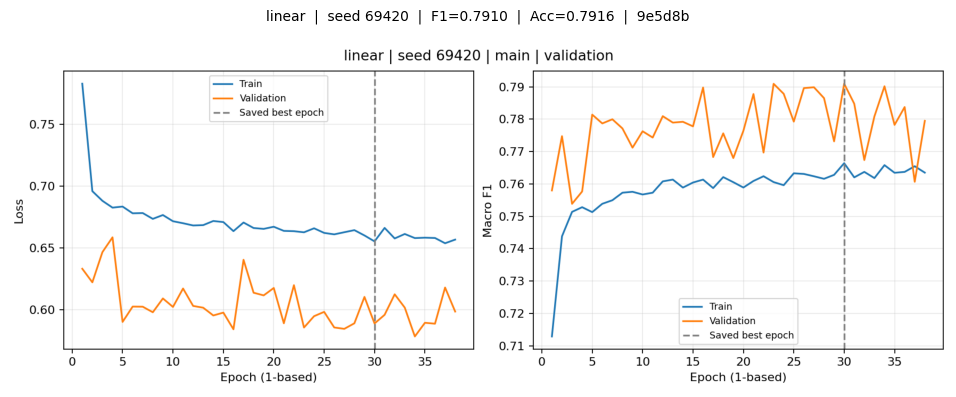

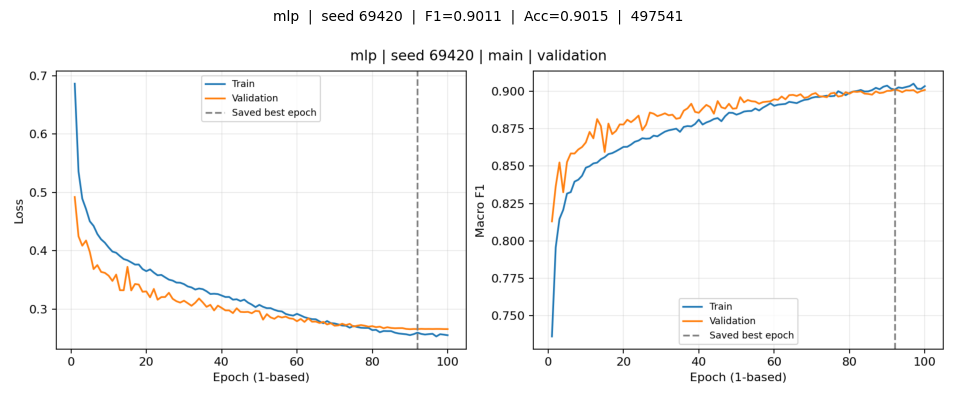

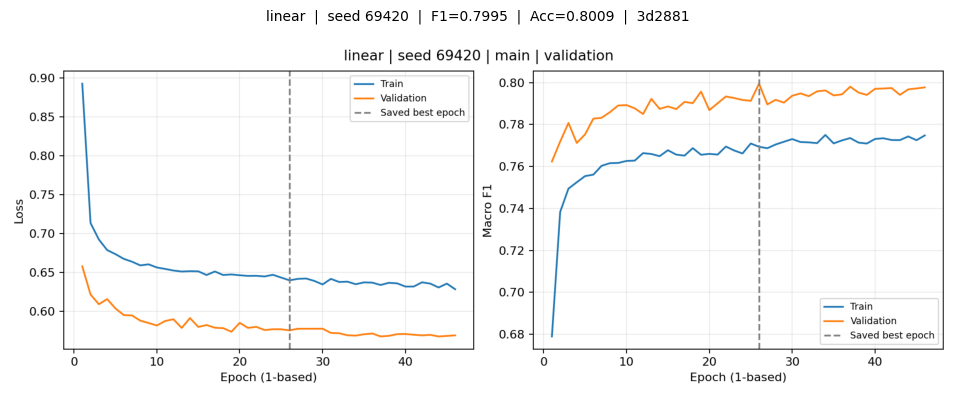

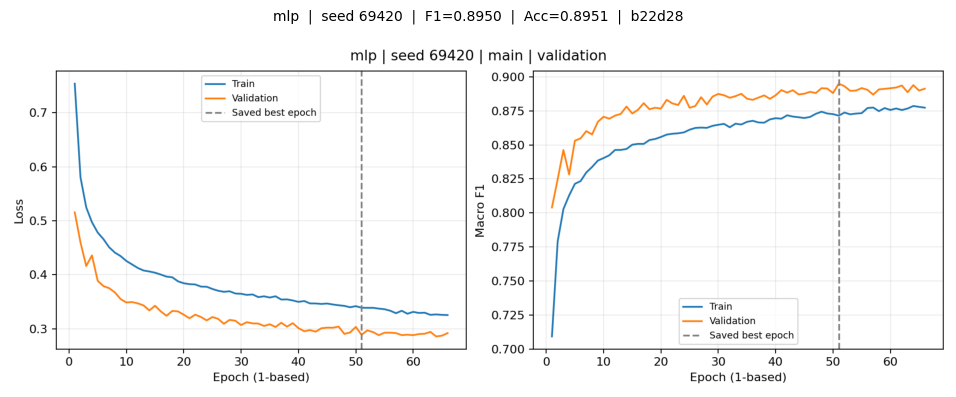

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

for run_id in RUN_IDS:
    s = summaries[run_id]
    img = plt.imread(str(OUTPUT_DIRS[run_id] / "learning_curves.png"))
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.imshow(img)
    ax.axis("off")
    fig.suptitle(
        f"{s['model']}  |  seed {s['seed']}  |  "
        f"F1={s['metrics']['val_macro_f1']:.4f}  |  Acc={s['metrics']['val_accuracy']:.4f}  |  "
        f"{run_id[-6:]}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRS[run_id] / "learning_curves_display.png", dpi=150)
    plt.show()

## 8 — Confusion Matrices

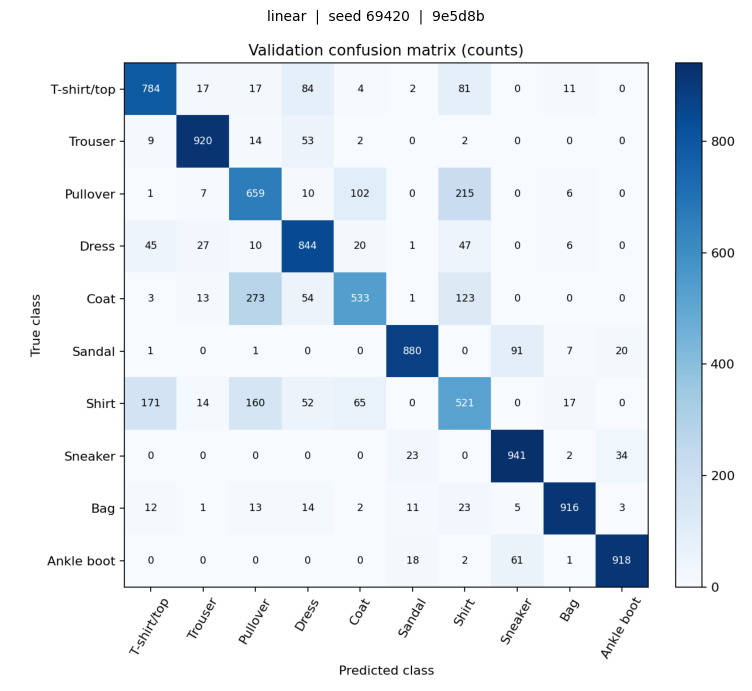

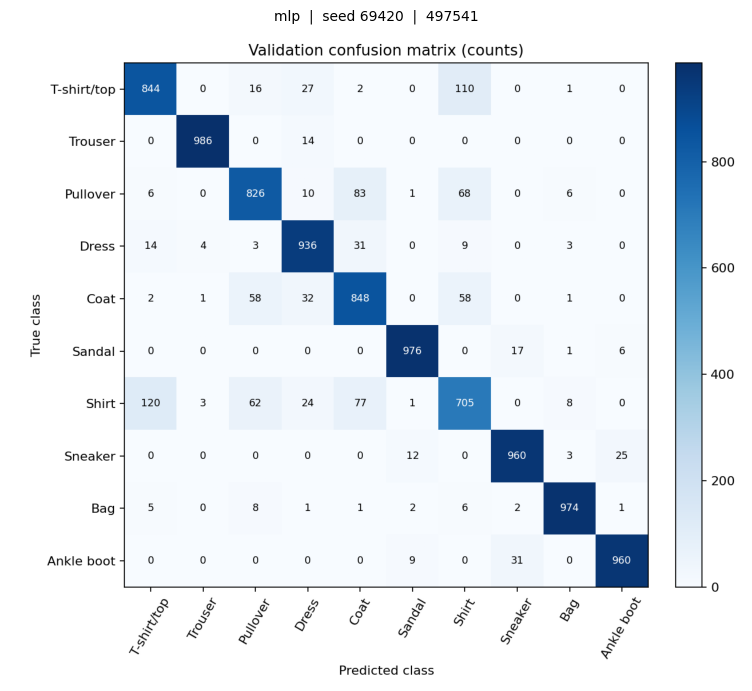

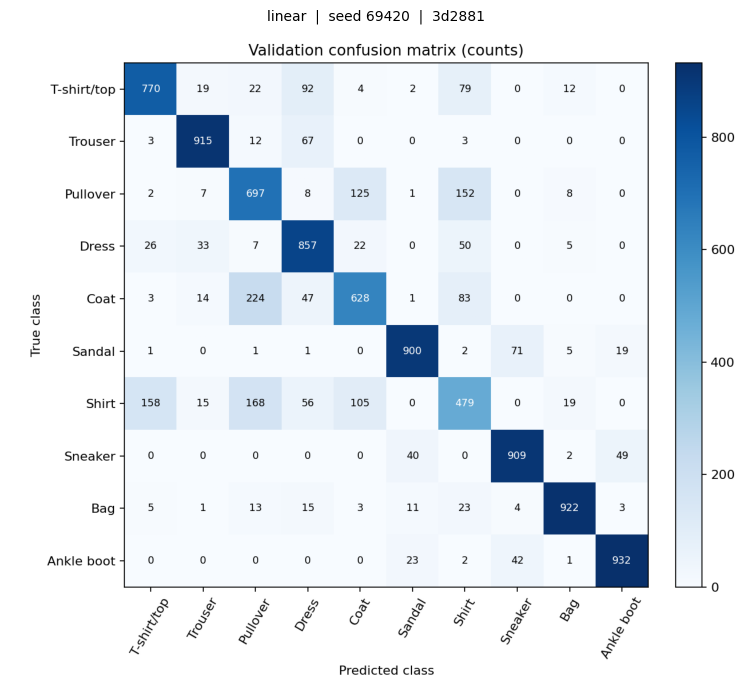

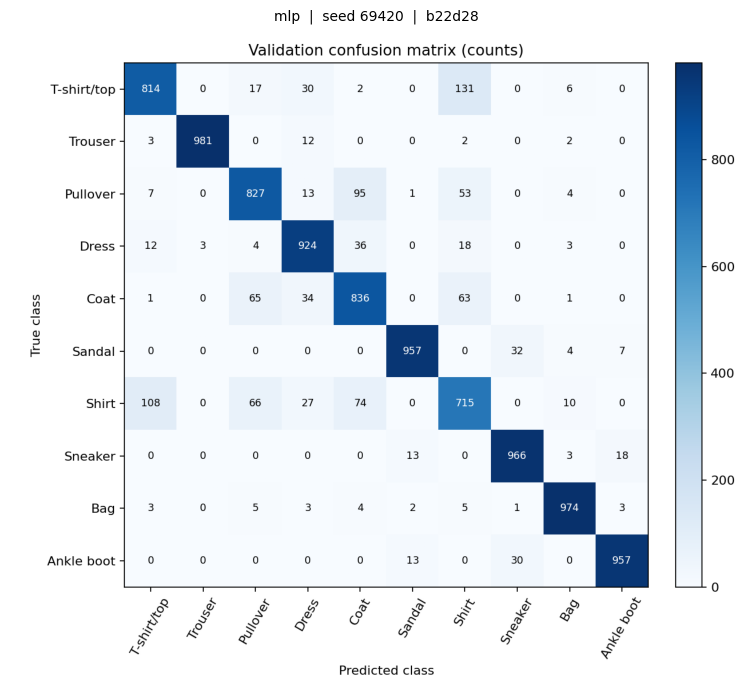

In [ ]:
for run_id in RUN_IDS:
    s = summaries[run_id]
    img = plt.imread(str(OUTPUT_DIRS[run_id] / "validation" / "confusion_validation.png"))
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(img)
    ax.axis("off")
    fig.suptitle(
        f"{s['model']}  |  seed {s['seed']}  |  {run_id[-6:]}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

## 9 — Benchmark Charts

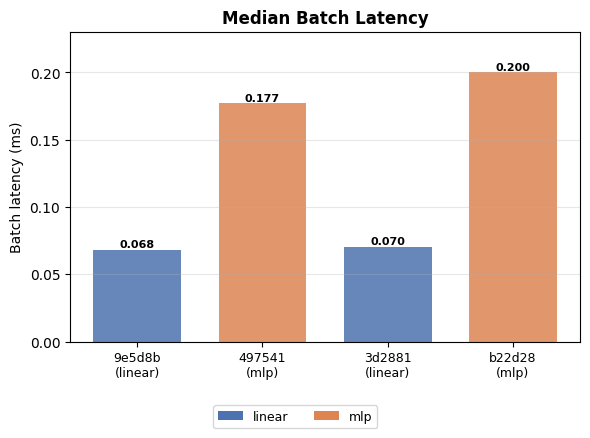

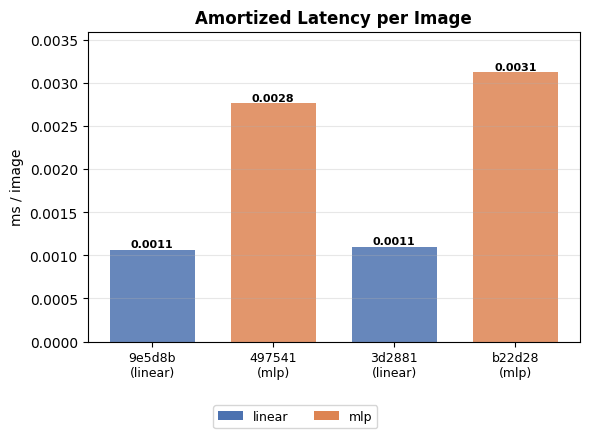

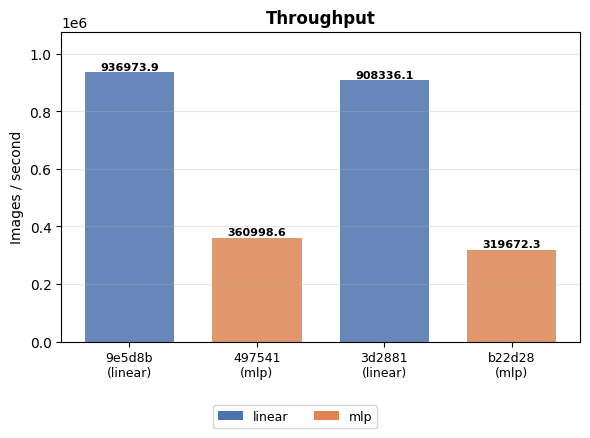

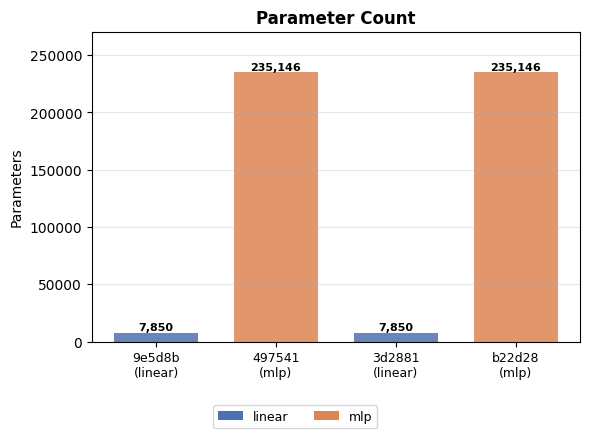

In [ ]:
bench_rows = [(rid, b) for rid, b in benchmarks.items() if b is not None]

if not bench_rows:
    print("No benchmark data found \u2014 re-run with --benchmark on a GPU runtime.")
else:
    labels = [r[-6:] for r, _ in bench_rows]
    models = [summaries[r]["model"] for r, _ in bench_rows]

    palette    = {}
    _base_cols = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
    for mdl in models:
        if mdl not in palette:
            palette[mdl] = _base_cols[len(palette) % len(_base_cols)]
    colors = [palette[m] for m in models]

    bar_w   = max(0.35, min(0.7, 4 / len(bench_rows)))
    x       = list(range(len(bench_rows)))
    xlabels = [f"{lbl}\n({mdl})" for lbl, mdl in zip(labels, models)]

    # (key, title, ylabel, label_fmt)
    METRICS = [
        ("median_batch_ms",       "Median Batch Latency",         "Batch latency (ms)",  "{:.3f}"),
        ("amortized_ms_per_image","Amortized Latency per Image",  "ms / image",          "{:.4f}"),
        ("images_per_second",     "Throughput",                   "Images / second",     "{:.1f}"),
        ("parameter_count",       "Parameter Count",              "Parameters",          "{:,d}"),
    ]

    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=c, label=m) for m, c in palette.items()]

    for key, title, ylabel, fmt in METRICS:
        values = [b[key] for _, b in bench_rows]
        fig, ax = plt.subplots(figsize=(max(5, 1.5 * len(bench_rows)), 4))
        bars = ax.bar(x, values, width=bar_w, color=colors, alpha=0.85)
        # Value labels on top of each bar
        for bar, val in zip(bars, values):
            label = fmt.format(int(val) if fmt.endswith("d}") else val)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center", va="bottom", fontsize=8, fontweight="bold",
            )
        # Add a little headroom so labels aren't clipped
        ax.set_ylim(0, max(values) * 1.15)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=9)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        fig.legend(handles=legend_handles, loc="lower center",
                   ncol=len(palette), fontsize=9, bbox_to_anchor=(0.5, -0.1))
        plt.tight_layout()
        plt.savefig(ANALYSIS_ROOT / f"benchmark_{key}.png", dpi=150, bbox_inches="tight")
        plt.show()

## 10 — Per-Run Error Analysis (Top Misclassifications)

In [ ]:
from dlbench.a1.data.dataset import load_official_dataset

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot",
]

# Load the raw (untransformed) FashionMNIST official train split once.
# All validation samples come from official_train (see dataset.py:46).
DATA_ROOT = str(project_root / "data")
raw_train = load_official_dataset(DATA_ROOT, train=True, download=True)
print(f"Loaded raw train dataset: {len(raw_train)} images")

Loaded raw train dataset: 60000 images


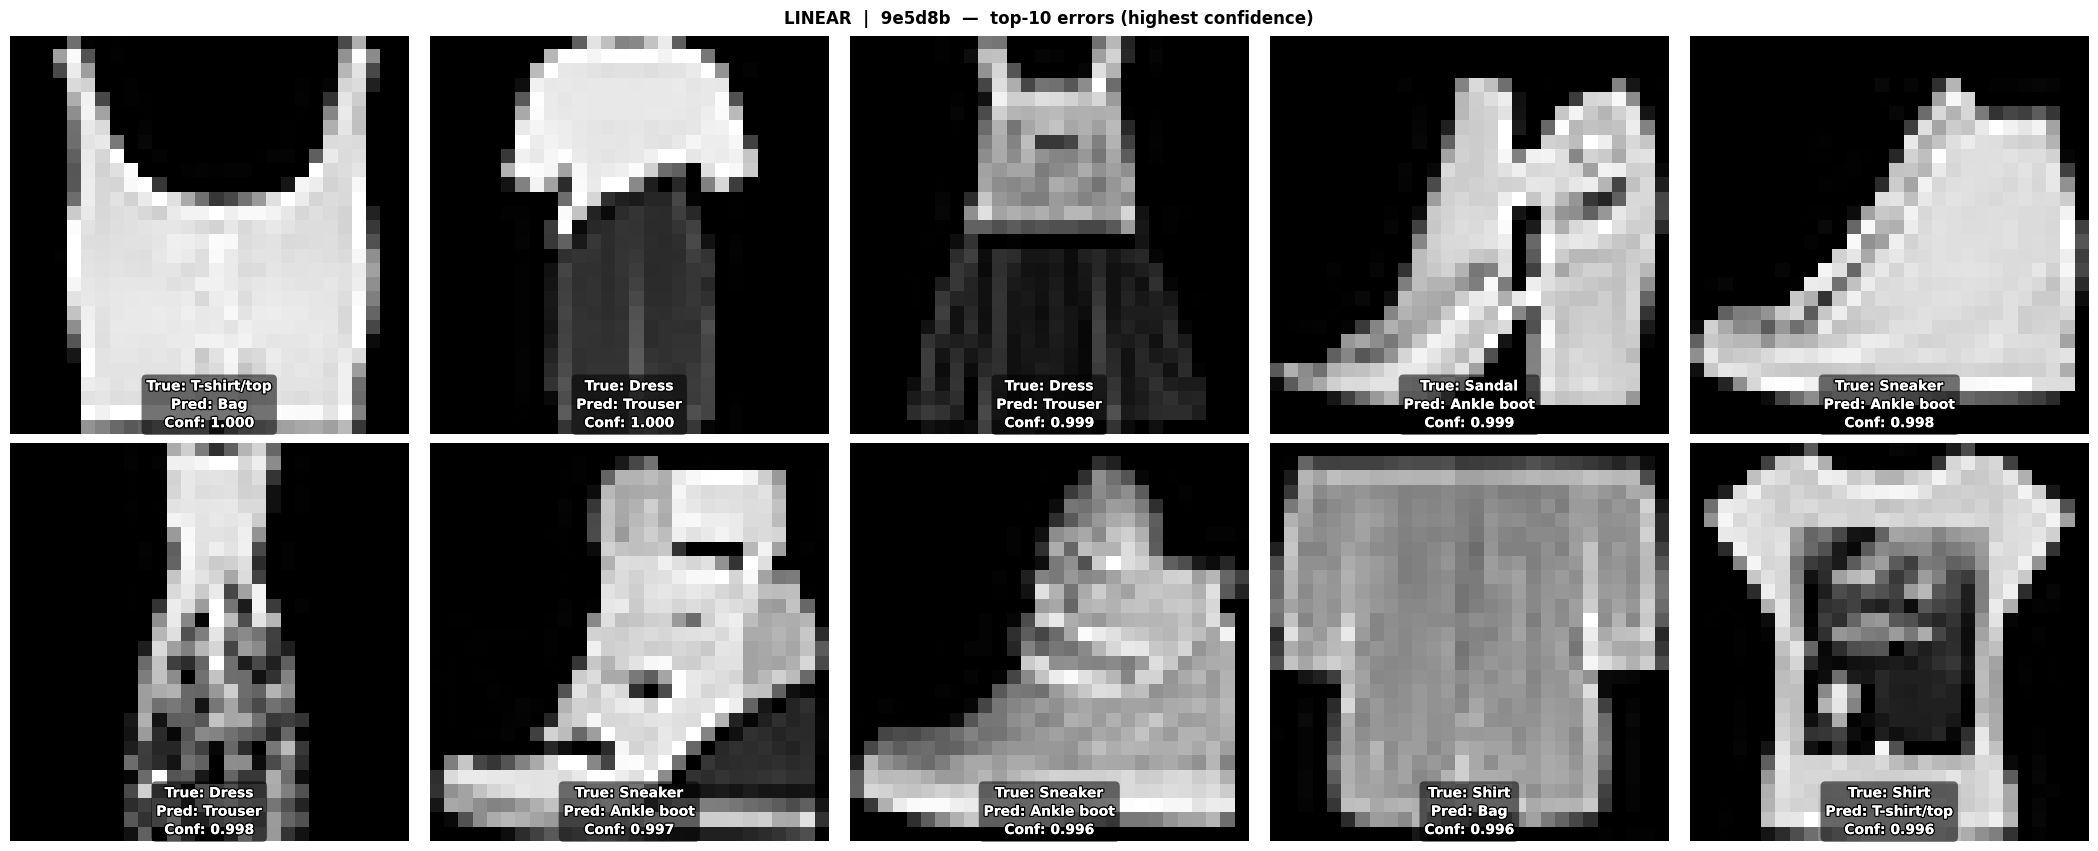

  Saved 10 images + grid to /content/Deep-Learning-Benchmark-Suite/analysis/a1_linear_main_seed69420_20260920-071742_9e5d8b/errors_gallery


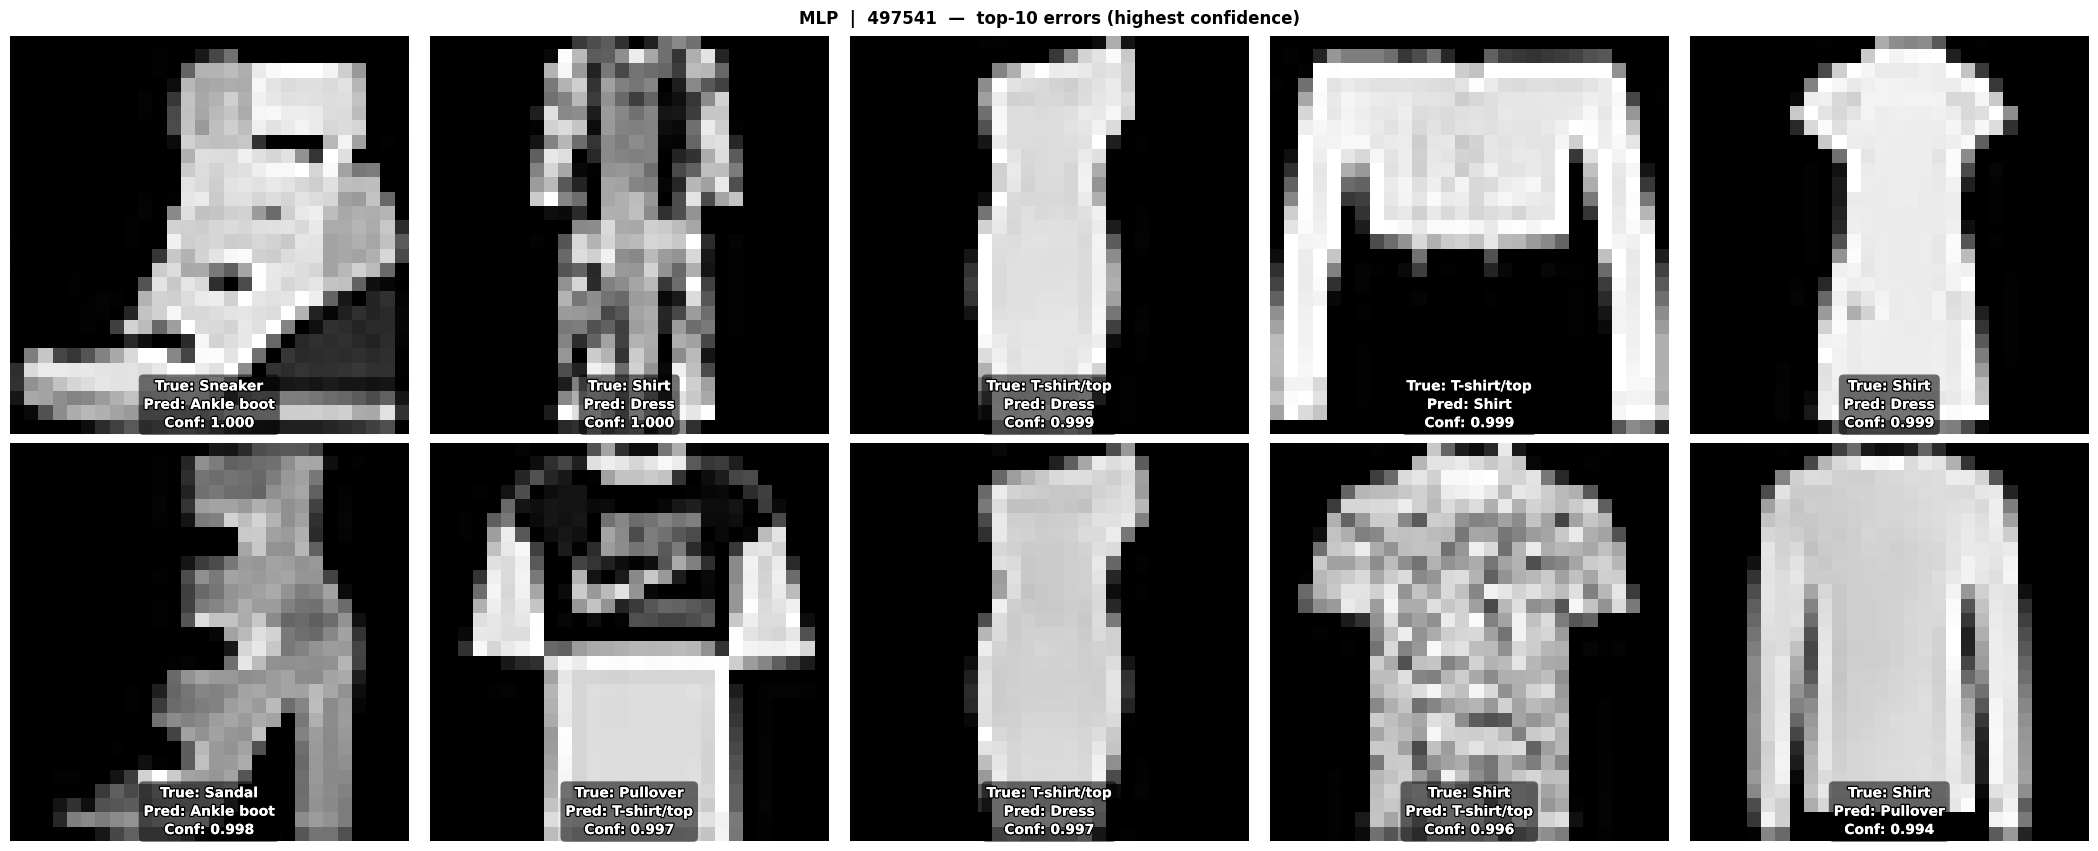

  Saved 10 images + grid to /content/Deep-Learning-Benchmark-Suite/analysis/a1_mlp_main_seed69420_20260920-073429_497541/errors_gallery


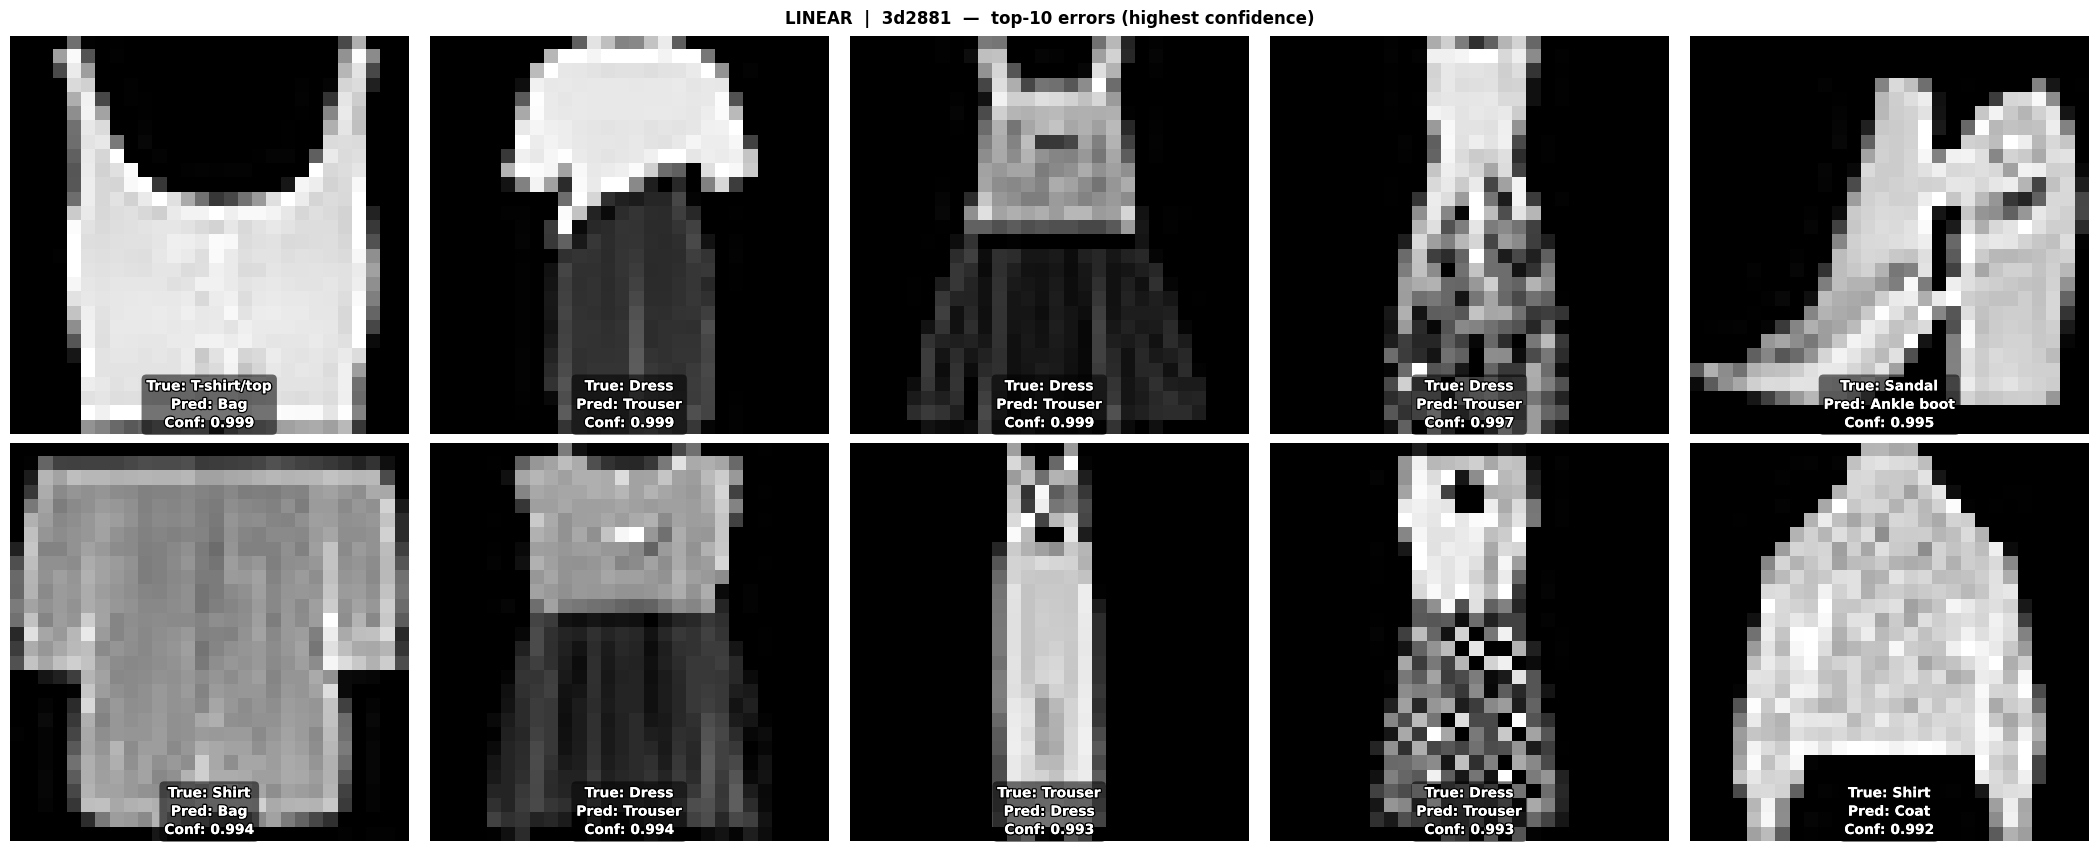

  Saved 10 images + grid to /content/Deep-Learning-Benchmark-Suite/analysis/a1_linear_main_seed69420_20260920-114825_3d2881/errors_gallery


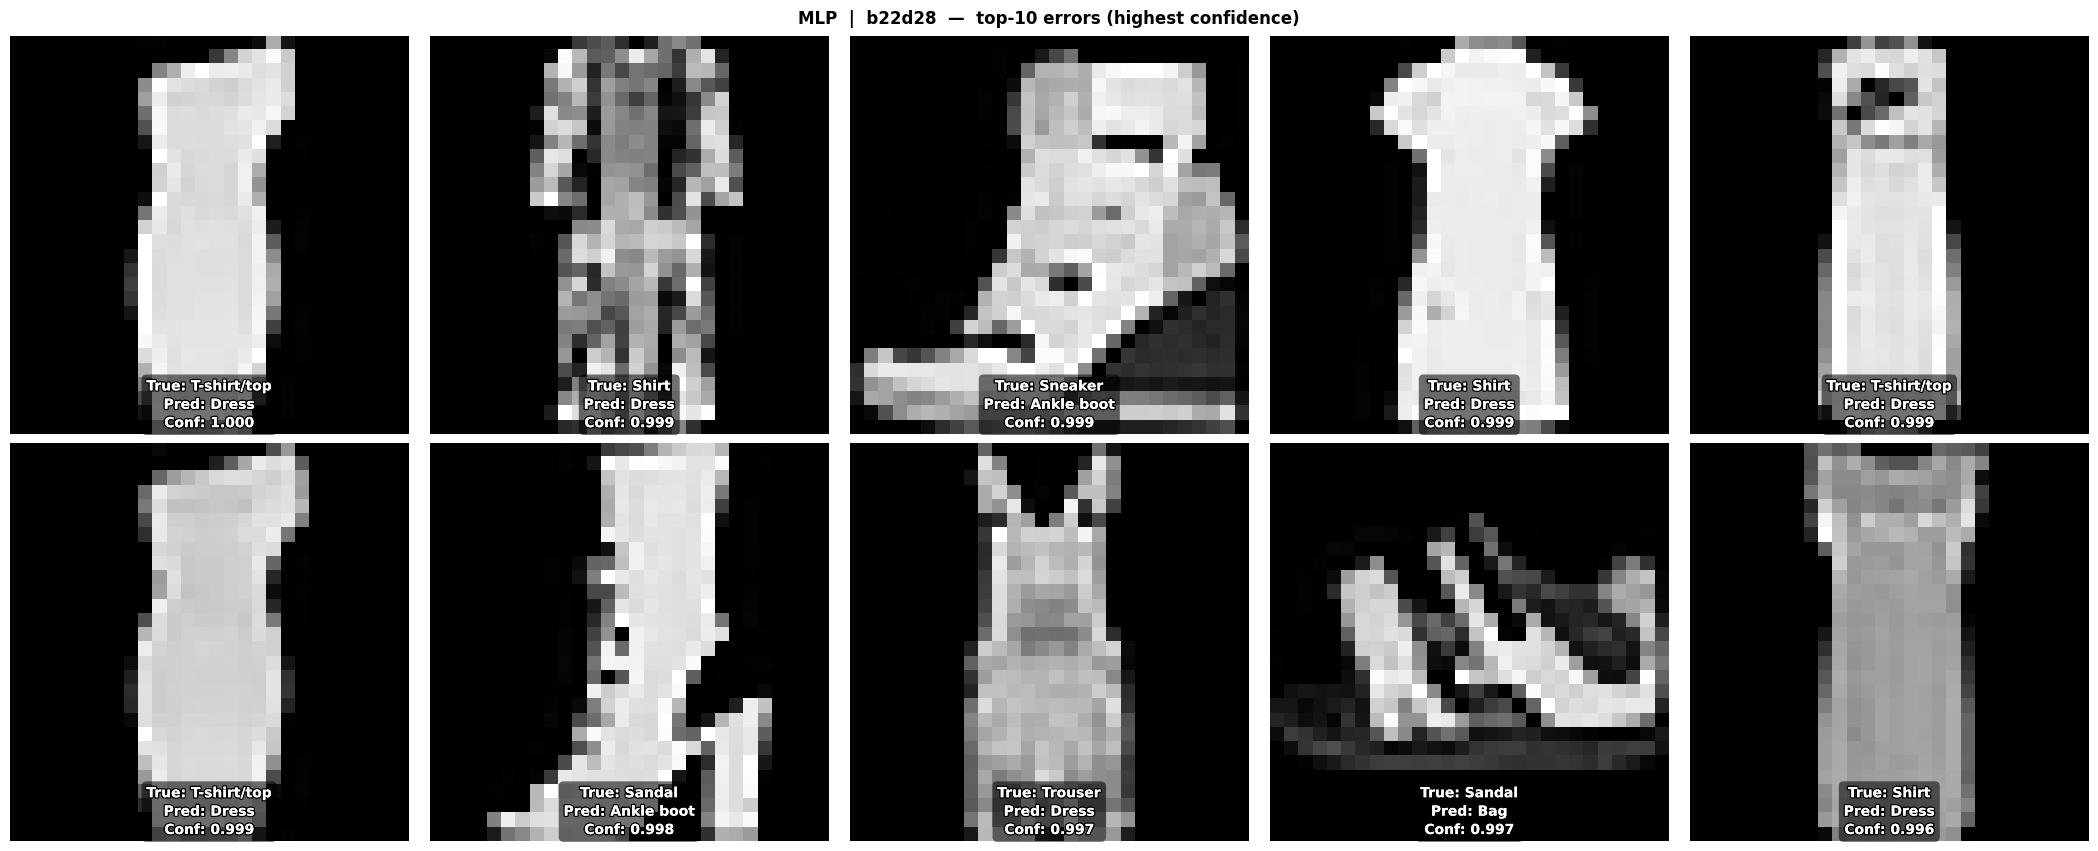

  Saved 10 images + grid to /content/Deep-Learning-Benchmark-Suite/analysis/a1_mlp_main_seed69420_20260920-120316_b22d28/errors_gallery


In [ ]:
import matplotlib.patheffects as pe

TOP_N    = 10   # errors to display and save per run
NCOLS    = 5    # columns in the gallery grid
CELL_PX  = 4.2  # inches per cell (width and height) — increase for more spacing

for run_id in RUN_IDS:
    errors_path = OUTPUT_DIRS[run_id] / "validation" / "errors.json"
    if not errors_path.exists():
        print(f"[{run_id}] No errors.json \u2014 skipping.")
        continue

    payload = json.loads(errors_path.read_text(encoding="utf-8"))
    errors  = payload["errors"][:TOP_N]   # already sorted by descending confidence
    model   = df.loc[run_id, "model"]

    # ── Save directory ────────────────────────────────────────────────────────
    gallery_dir = OUTPUT_DIRS[run_id] / "errors_gallery"
    gallery_dir.mkdir(parents=True, exist_ok=True)

    # ── Fetch raw PIL images and save individually ────────────────────────────
    pil_images = []
    for e in errors:
        source_idx = int(e["sample_id"].split(":")[-1])
        pil_img, _ = raw_train[source_idx]
        pil_images.append(pil_img)

        fname = (
            f"idx{source_idx}"
            f"_true_{e['target']}_{CLASS_NAMES[e['target']].replace('/', '-')}"
            f"_pred_{e['predicted_label']}_{CLASS_NAMES[e['predicted_label']].replace('/', '-')}"
            f"_conf{e['confidence']:.4f}.png"
        )
        pil_img.save(gallery_dir / fname)

    # ── Display as a labelled grid ────────────────────────────────────────────
    ncols = min(len(errors), NCOLS)
    nrows = math.ceil(len(errors) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(CELL_PX * ncols, CELL_PX * nrows),
        constrained_layout=True,   # handles spacing automatically
    )
    # Ensure axes is always 2-D
    if nrows == 1:
        axes = [axes] if ncols == 1 else [axes]
    axes_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

    fig.suptitle(
        f"{model.upper()}  |  {run_id[-6:]}  \u2014  top-{TOP_N} errors (highest confidence)",
        fontsize=12, fontweight="bold",
    )

    for ax, e, pil_img in zip(axes_flat, errors, pil_images):
        ax.imshow(pil_img, cmap="gray", interpolation="nearest")
        ax.axis("off")

        true_name = CLASS_NAMES[e["target"]]
        pred_name = CLASS_NAMES[e["predicted_label"]]
        label     = f"True: {true_name}\nPred: {pred_name}\nConf: {e['confidence']:.3f}"

        # Text sits inside the image at the bottom, with a semi-transparent
        # dark background box so it never bleeds into neighbouring cells.
        txt = ax.text(
            0.5, 0.01, label,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=10, color="white", fontweight="bold",
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="black", alpha=0.55,
                edgecolor="none",
            ),
        )
        # Drop-shadow for legibility on light pixels
        txt.set_path_effects([
            pe.withStroke(linewidth=2, foreground="black"),
            pe.Normal(),
        ])

    for ax in axes_flat[len(errors):]:
        ax.set_visible(False)

    grid_path = gallery_dir / "errors_grid.png"
    plt.savefig(grid_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {len(errors)} images + grid to {gallery_dir}")

## 11 — Full Benchmark JSON (Provenance)

In [ ]:
import pprint

for run_id, b in benchmarks.items():
    print(f"\n{'\u2550' * 62}")
    print(f"  {run_id}")
    print(f"{'\u2550' * 62}")
    if b is None:
        print("  [No benchmark \u2014 re-run with --benchmark on a GPU runtime]")
    else:
        pprint.pprint(b, indent=4)


══════════════════════════════════════════════════════════════
  a1_linear_main_seed69420_20260920-071742_9e5d8b
══════════════════════════════════════════════════════════════
{   'amortized_ms_per_image': 0.0010672656252097568,
    'batch_ms_samples': [   0.08193599990136136,
                            0.06972599999244267,
                            0.06744799998159579,
                            0.06974999996600673,
                            0.08921799997096969,
                            0.13390200001595076,
                            0.07372799996119284,
                            0.08329000002049725,
                            0.11517500001900771,
                            0.08199399997010914,
                            0.07111900004019844,
                            0.06897100001879153,
                            0.06764799991287873,
                            0.06807700003719219,
                            0.10605299996768736,
                            0.11525

## 12 — Save Combined Comparison CSV

In [ ]:
csv_path = ANALYSIS_ROOT / "comparison.csv"
df.to_csv(csv_path)
print("Saved:", csv_path)
display(df)

Saved: /content/Deep-Learning-Benchmark-Suite/analysis/comparison.csv


,model,seed,epochs,best_epoch,val_loss,val_accuracy,val_macro_f1,train_time_s,median_batch_ms,amortized_ms_per_img,images_per_second,batch_size,parameter_count,amortized_ms_per_image
run_id,,,,,,,,,,,,,,
a1_linear_main_seed69420_20260920-071742_9e5d8b,linear,69420,38,29,0.588840,0.7916,0.790977,751.3,0.068305,0.0011,936973.867029,64,7850,0.001067
a1_mlp_main_seed69420_20260920-073429_497541,mlp,69420,100,91,0.265457,0.9015,0.901141,2031.2,0.177286,0.0028,360998.612420,64,235146,0.002770
a1_linear_main_seed69420_20260920-114825_3d2881,linear,69420,46,25,0.575779,0.8009,0.799487,876.2,0.070458,0.0011,908336.113048,64,7850,0.001101
a1_mlp_main_seed69420_20260920-120316_b22d28,mlp,69420,66,50,0.288985,0.8951,0.895012,1302.7,0.200205,0.0031,319672.335858,64,235146,0.003128
